# Results Analysis

Loads all per-run JSON files from `results/`, builds comparison tables and plots.

**Datasets:** optdigits · mnist · landsat · backdoor  
**Variants:** 26 per dataset
- 4 deep teachers (vanilla, cnn, transformer, vae)
- 3 Big-Kitsune teachers (`bigkit_r4`, `bigkit_r16`, `bigkit_r32`)
- 1 Kitsune baseline (no KD)
- 9 PKT students with deep teachers (concat + per_subae for all 4 teachers, plus token routing for transformer)
- 9 PKT students with Big-Kitsune teachers (concat + per_subae + subae_paired for each of 3 ratios)

**Seeds:** 42, 123, 456

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['optdigits', 'mnist', 'landsat', 'backdoor']
TEACHERS = ['vanilla', 'cnn', 'transformer', 'vae']
BIGKIT_TEACHERS = ['bigkit_r4', 'bigkit_r16', 'bigkit_r32']
BIGKIT_RATIOS = [4, 16, 32]
BASELINE = 'kitsune_vanilla'

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

In [2]:
# Load all result JSON files (skip sweep/ subdirectory)
records = []
for f in RESULTS_DIR.glob('*.json'):
    with open(f) as fh:
        records.append(json.load(fh))

df = pd.DataFrame(records)

# Keep only the 4 target datasets
df = df[df['dataset'].isin(DATASETS)]

print(f'Loaded {len(df)} results across {df["dataset"].nunique()} datasets and {df["model"].nunique()} model variants')
df.head()

Loaded 360 results across 4 datasets and 30 model variants


,auc_roc,auc_pr,f1_oracle,params,inference_time_ms,phi,f1_phi,dataset,model,seed
0,0.867329,0.756209,0.782744,26208,0.048199,0.499185,0.170463,backdoor,bigkit_mix_r4,123
1,0.902167,0.622346,0.827364,26208,0.045801,0.532389,0.001715,backdoor,bigkit_mix_r4,42
2,0.906564,0.825529,0.866555,26208,0.054546,0.340103,0.323741,backdoor,bigkit_mix_r4,456
3,0.952210,0.868092,0.899678,97650,0.031899,0.309157,0.022920,backdoor,bigkit_r16,123
4,0.954254,0.867396,0.897656,97650,0.032216,0.310880,0.034585,backdoor,bigkit_r16,42


In [3]:
# Mean ± std summary table (AUC-ROC) — rows = models, columns = datasets
metrics = ['auc_roc', 'auc_pr', 'f1_oracle', 'f1_phi', 'params', 'inference_time_ms']
agg = df.groupby(['dataset', 'model'])[metrics].agg(['mean', 'std']).round(4)

# Readable mean±std pivot for AUC-ROC
def fmt(row):
    return f"{row['mean']:.3f}±{row['std']:.3f}"

pivot = (
    df.groupby(['dataset', 'model'])['auc_roc']
    .agg(['mean', 'std'])
    .apply(fmt, axis=1)
    .unstack('dataset')
    [DATASETS]
)
pivot

dataset,optdigits,mnist,landsat,backdoor
model,,,,
bigkit_mix_r4,0.711±0.052,0.919±0.017,0.473±0.080,0.892±0.021
bigkit_r16,0.667±0.022,0.851±0.012,0.590±0.024,0.955±0.004
bigkit_r32,0.633±0.025,0.822±0.008,0.610±0.030,0.968±0.005
bigkit_r4,0.706±0.051,0.947±0.003,0.493±0.011,0.943±0.005
cnn,0.681±0.048,0.321±0.002,0.250±0.002,0.321±0.001
kitsune_pkt_bigkit_mix_r4,0.703±0.105,0.775±0.043,0.540±0.076,0.907±0.032
kitsune_pkt_bigkit_mix_r4_per_subae,0.733±0.095,0.781±0.043,0.549±0.031,0.901±0.013
kitsune_pkt_bigkit_mix_r4_subae_paired,0.700±0.119,0.815±0.053,0.563±0.033,0.911±0.032
kitsune_pkt_bigkit_r16,0.663±0.068,0.785±0.055,0.547±0.058,0.907±0.007


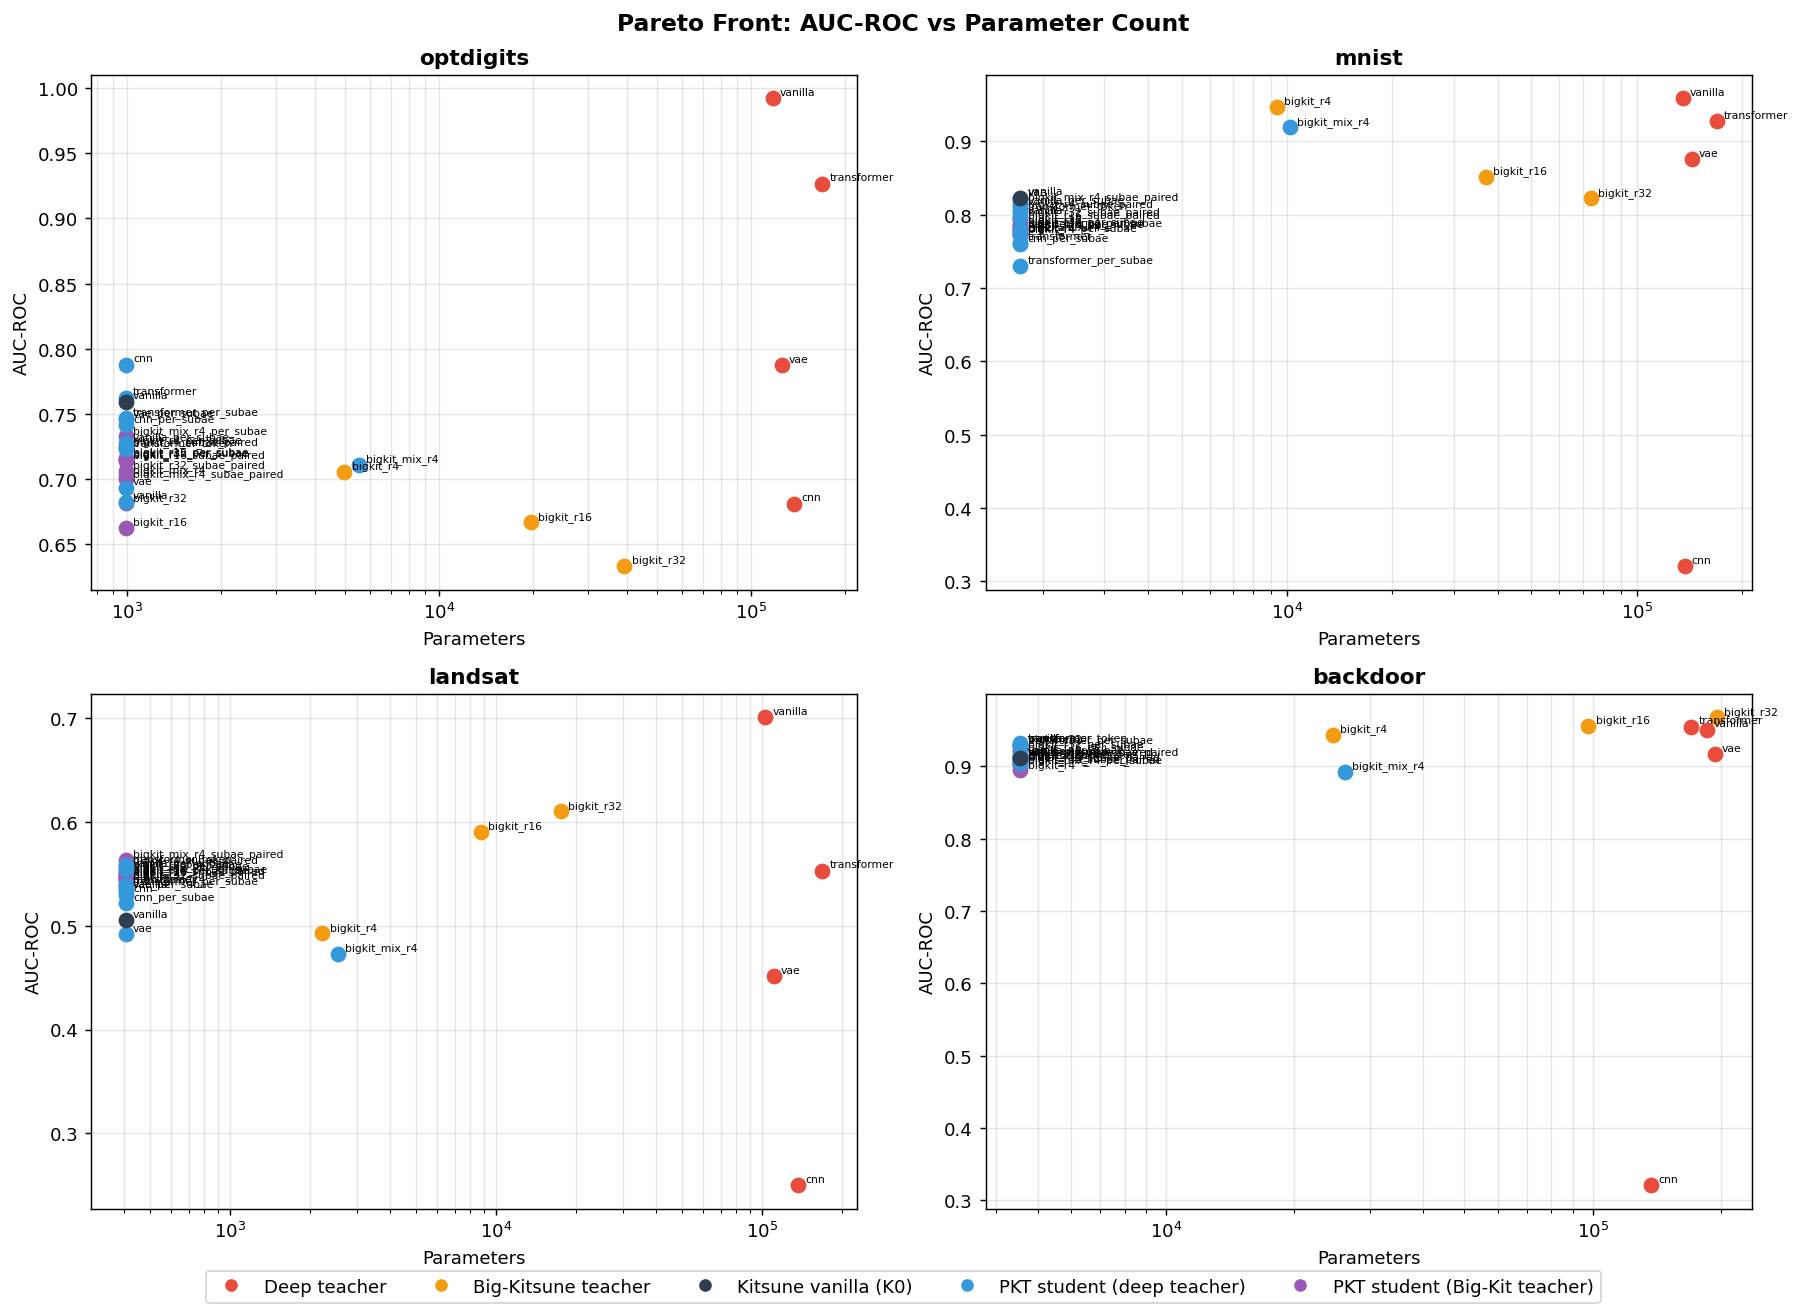

In [4]:
# Pareto plot: AUC-ROC vs parameter count (2×2 grid, one panel per dataset)
means = df.groupby(['dataset', 'model'])[['auc_roc', 'params']].mean().reset_index()

# Colour: deep teacher / big-kitsune teacher / kitsune baseline / deep-teacher PKT student / big-kitsune PKT student
def model_color(m):
    if m in TEACHERS:
        return '#e74c3c'        # red    — deep teacher
    elif m in BIGKIT_TEACHERS:
        return '#f39c12'        # orange — Big-Kitsune teacher (standalone)
    elif m == BASELINE:
        return '#2c3e50'        # dark   — kitsune vanilla baseline
    elif m.startswith('kitsune_pkt_bigkit'):
        return '#9b59b6'        # purple — Big-Kitsune-distilled PKT student
    else:
        return '#3498db'        # blue   — deep-teacher PKT student

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.flatten()

for ax, dataset in zip(axes, DATASETS):
    sub = means[means['dataset'] == dataset]
    for _, row in sub.iterrows():
        color = model_color(row['model'])
        ax.scatter(row['params'], row['auc_roc'], color=color, s=60, zorder=3)
        ax.annotate(
            row['model'].replace('kitsune_', '').replace('pkt_', ''),
            (row['params'], row['auc_roc']),
            fontsize=6, xytext=(4, 2), textcoords='offset points'
        )
    ax.set_title(dataset, fontweight='bold')
    ax.set_xlabel('Parameters')
    ax.set_ylabel('AUC-ROC')
    ax.set_xscale('log')   # log scale handles the wide range from 406 (kit_landsat) to ~200K (vanilla_backdoor)
    ax.grid(True, alpha=0.3, which='both')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Deep teacher'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12', markersize=8, label='Big-Kitsune teacher'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2c3e50', markersize=8, label='Kitsune vanilla (K0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='PKT student (deep teacher)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6', markersize=8, label='PKT student (Big-Kit teacher)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Pareto Front: AUC-ROC vs Parameter Count', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pareto.png', dpi=150, bbox_inches='tight')
plt.show()

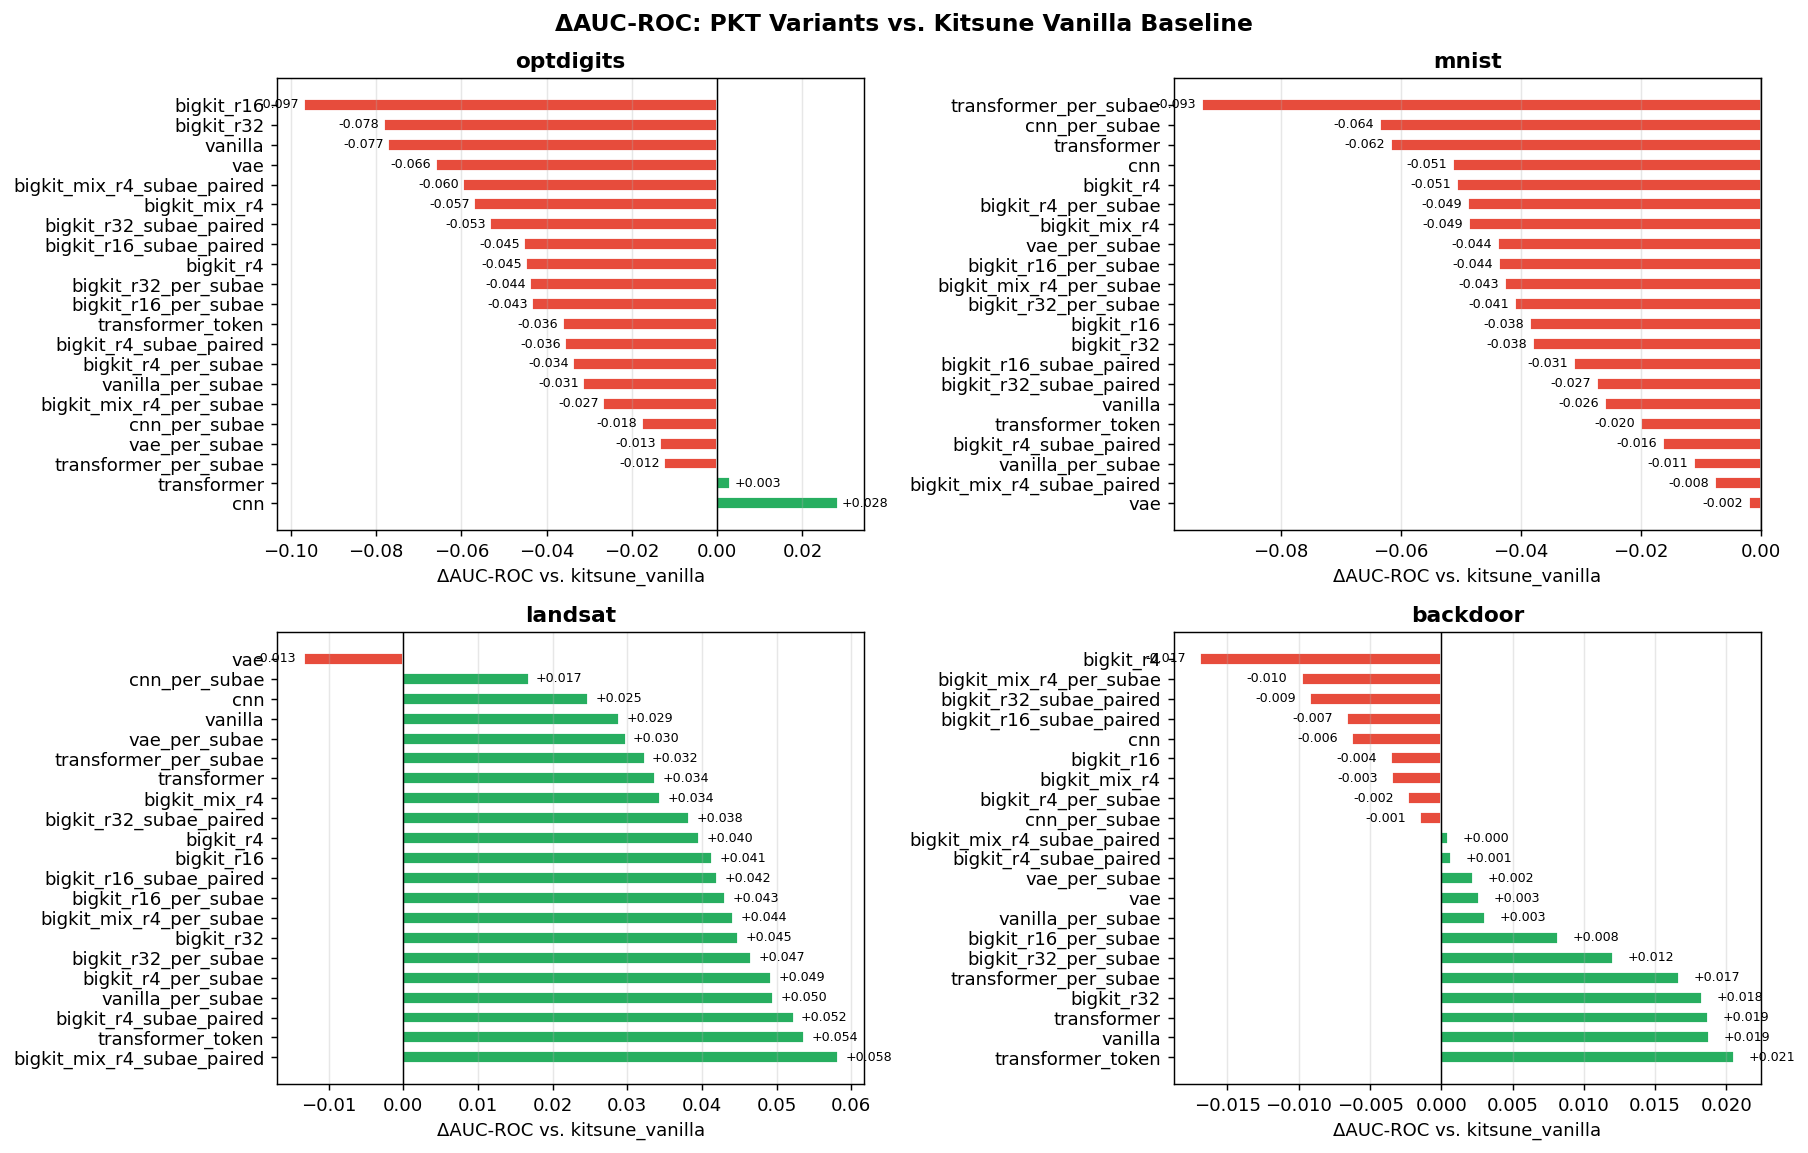

In [5]:
# Delta AUC-ROC: PKT variants vs. kitsune_vanilla baseline (per dataset)
mean_auc = df.groupby(['dataset', 'model'])['auc_roc'].mean().unstack('model')

pkt_models = [m for m in mean_auc.columns if m.startswith('kitsune_pkt')]
delta = mean_auc[pkt_models].subtract(mean_auc[BASELINE], axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes = axes.flatten()

for ax, dataset in zip(axes, DATASETS):
    row = delta.loc[dataset].sort_values(ascending=False)
    colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in row.values]
    bars = ax.barh(
        [m.replace('kitsune_pkt_', '') for m in row.index],
        row.values,
        color=colors,
        edgecolor='white',
        height=0.6
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(dataset, fontweight='bold')
    ax.set_xlabel('ΔAUC-ROC vs. kitsune_vanilla')
    ax.grid(True, axis='x', alpha=0.3)
    # Annotate bar values
    for bar, val in zip(bars, row.values):
        ax.text(
            val + (0.001 if val >= 0 else -0.001),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=7
        )

plt.suptitle('ΔAUC-ROC: PKT Variants vs. Kitsune Vanilla Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'delta_auc.png', dpi=150, bbox_inches='tight')
plt.show()

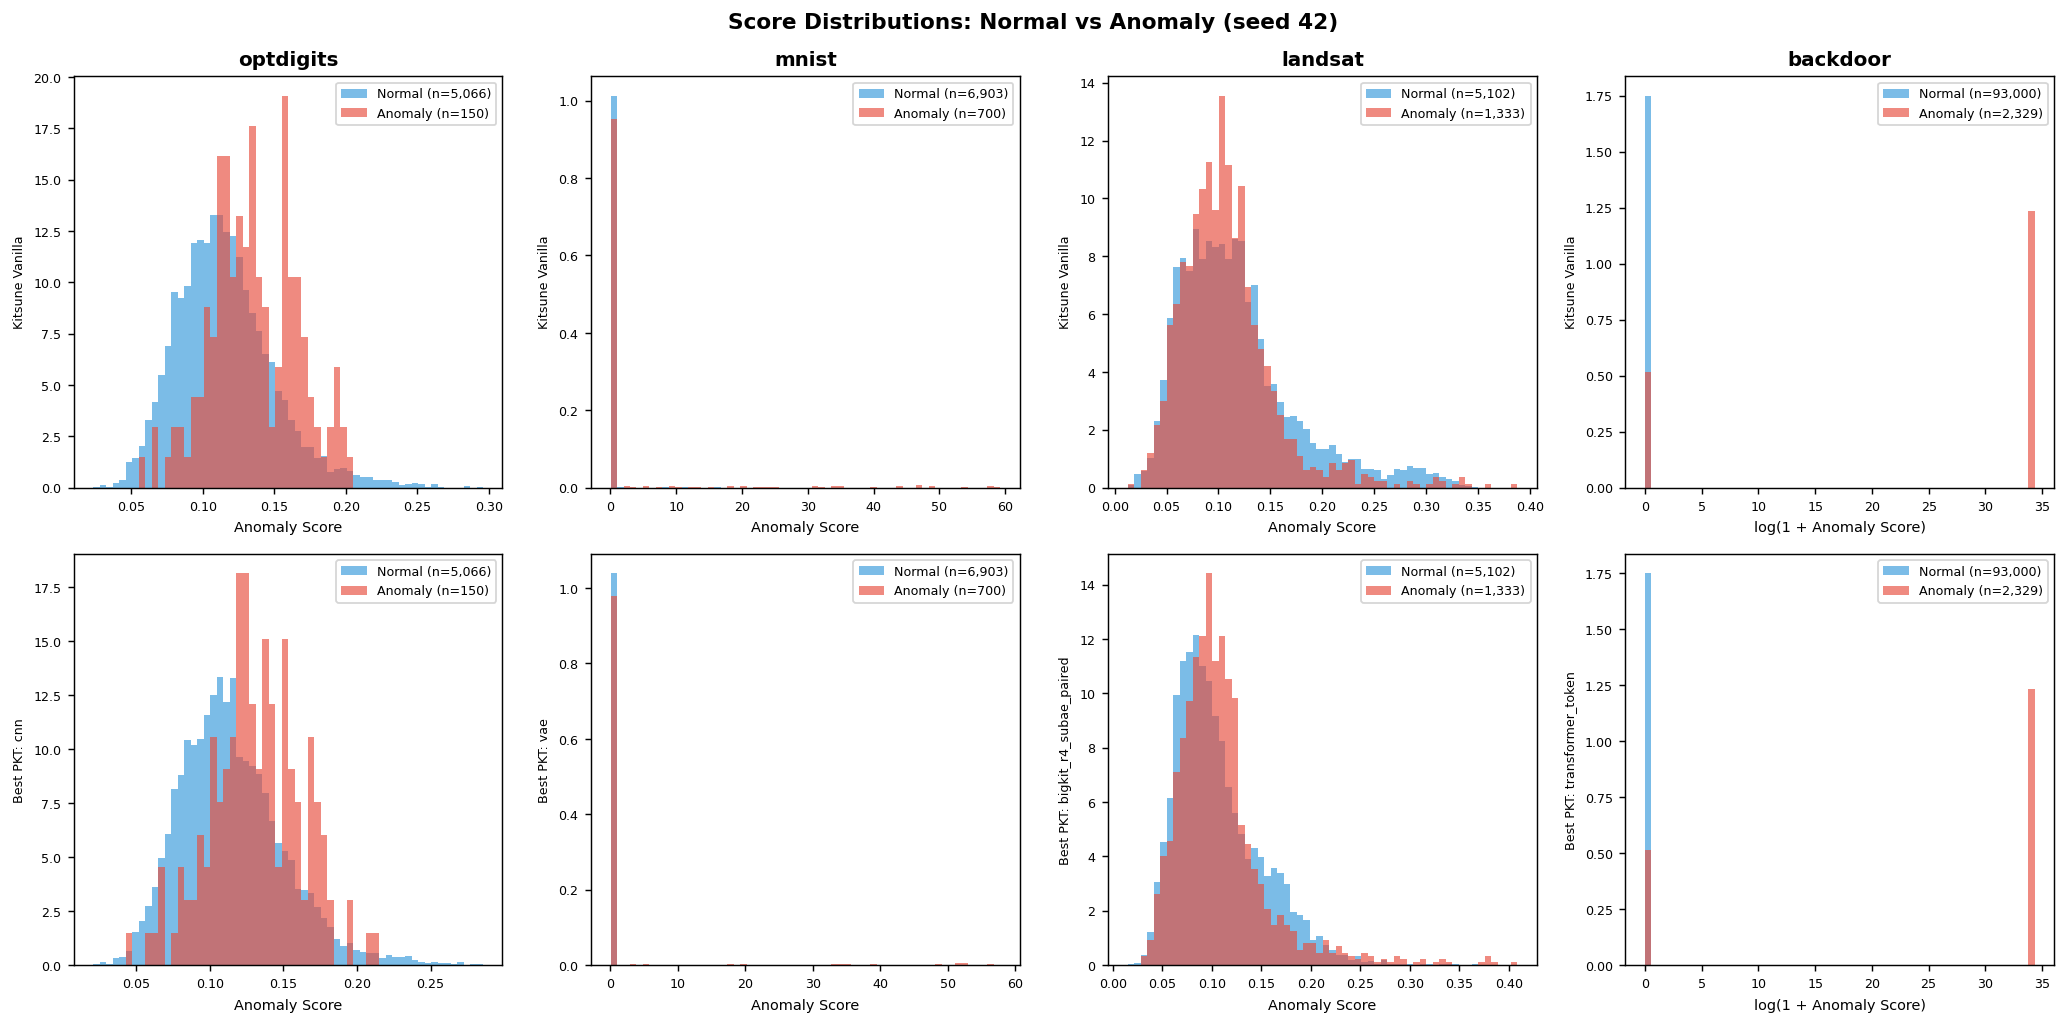

In [6]:
import sys, re
sys.path.insert(0, str(Path('..').resolve()))

import torch
from models.kitsune import KitsunePyTorch
from data.loader import load_dataset

LOG_SCALE_DATASETS = {'backdoor'}


def get_scores(dataset: str, model_name: str, seed: int):
    """Load any kitsune-family checkpoint and return (scores, labels). Bigkit-aware:
    parses hidden_ratio out of 'bigkit_r{R}' / 'kitsune_pkt_bigkit_r{R}*' names,
    instantiates KitsunePyTorch with the right ratio, and uses direct_rmse_sum
    for the standalone bigkit teacher (which has no trained output AE)."""
    ckpt_path = Path('..') / 'checkpoints' / f'{dataset}_{model_name}_seed{seed}.pt'
    if not ckpt_path.exists():
        return None, None
    _, _, test_loader, cfg = load_dataset(dataset, batch_size=512, seed=seed)

    is_bigkit_teacher = model_name.startswith('bigkit')
    has_bigkit_in_name = 'bigkit' in model_name
    if has_bigkit_in_name:
        # standalone teacher uses its own ratio; PKT student loaded with default 0.75
        if is_bigkit_teacher:
            r = int(re.search(r'bigkit_r(\d+)', model_name).group(1))
            model = KitsunePyTorch(cfg['n_features'], cfg['k_groups'], hidden_ratio=float(r))
        else:
            model = KitsunePyTorch(cfg['n_features'], cfg['k_groups'])  # student is always default
    else:
        model = KitsunePyTorch(cfg['n_features'], cfg['k_groups'])

    ckpt = torch.load(ckpt_path, map_location='cpu')
    state_dict = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
    model.load_state_dict(state_dict)
    model.eval()

    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            if is_bigkit_teacher:
                # output AE was never trained — score via direct sum of per-group RMSE
                s = model.direct_rmse_sum(x)
            else:
                s = model.get_anomaly_score(x)
            all_scores.append(s.numpy())
            all_labels.append(y.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


# Current best PKT variant per dataset (per RESEARCH_STATE §7.8 / README results)
COMPARISONS = {
    'optdigits': ('kitsune_vanilla', 'kitsune_pkt_cnn'),                    # +0.029
    'mnist':     ('kitsune_vanilla', 'kitsune_pkt_vae'),                    # ≈ tie
    'landsat':   ('kitsune_vanilla', 'kitsune_pkt_bigkit_r4_subae_paired'), # +0.047 (NEW: bigkit wins)
    'backdoor':  ('kitsune_vanilla', 'kitsune_pkt_transformer_token'),      # +0.021
}
SEED = 42

fig, axes = plt.subplots(2, len(DATASETS), figsize=(16, 8))

for col, dataset in enumerate(DATASETS):
    baseline_name, pkt_name = COMPARISONS[dataset]
    use_log = dataset in LOG_SCALE_DATASETS

    for row, (model_name, title) in enumerate([
        (baseline_name, 'Kitsune Vanilla'),
        (pkt_name,      f'Best PKT: {pkt_name.replace("kitsune_pkt_", "")}'),
    ]):
        ax = axes[row, col]
        scores, labels = get_scores(dataset, model_name, SEED)

        if scores is None:
            ax.text(0.5, 0.5, f'Checkpoint\nnot found:\n{model_name}',
                    ha='center', va='center', transform=ax.transAxes, color='gray', fontsize=8)
        else:
            if use_log:
                scores = np.log1p(scores)
                xlabel = 'log(1 + Anomaly Score)'
            else:
                xlabel = 'Anomaly Score'

            # Shared bin edges so both classes use the same x-range
            bins = np.histogram_bin_edges(scores, bins=60)

            ax.hist(scores[labels == 0], bins=bins, alpha=0.65, color='#3498db',
                    label=f'Normal (n={int((labels==0).sum()):,})', density=True)
            ax.hist(scores[labels == 1], bins=bins, alpha=0.65, color='#e74c3c',
                    label=f'Anomaly (n={int((labels==1).sum()):,})', density=True)
            ax.legend(fontsize=7)
            ax.set_xlabel(xlabel, fontsize=8)

        if row == 0:
            ax.set_title(dataset, fontweight='bold', fontsize=11)
        ax.set_ylabel(title, fontsize=7)
        ax.tick_params(labelsize=7)

plt.suptitle(f'Score Distributions: Normal vs Anomaly (seed {SEED})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'score_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## Big-Kitsune Capacity Sweep

Does increasing the Big-Kitsune teacher's `hidden_ratio` improve (a) standalone teacher performance and (b) the distilled student? Plot both as a function of `r ∈ {4, 16, 32}`, one line per dataset.

Standalone teacher uses **direct RMSE sum** scoring (output AE never trained). Student uses the standard output-AE-routed score, averaged over routings to keep the curve clean.

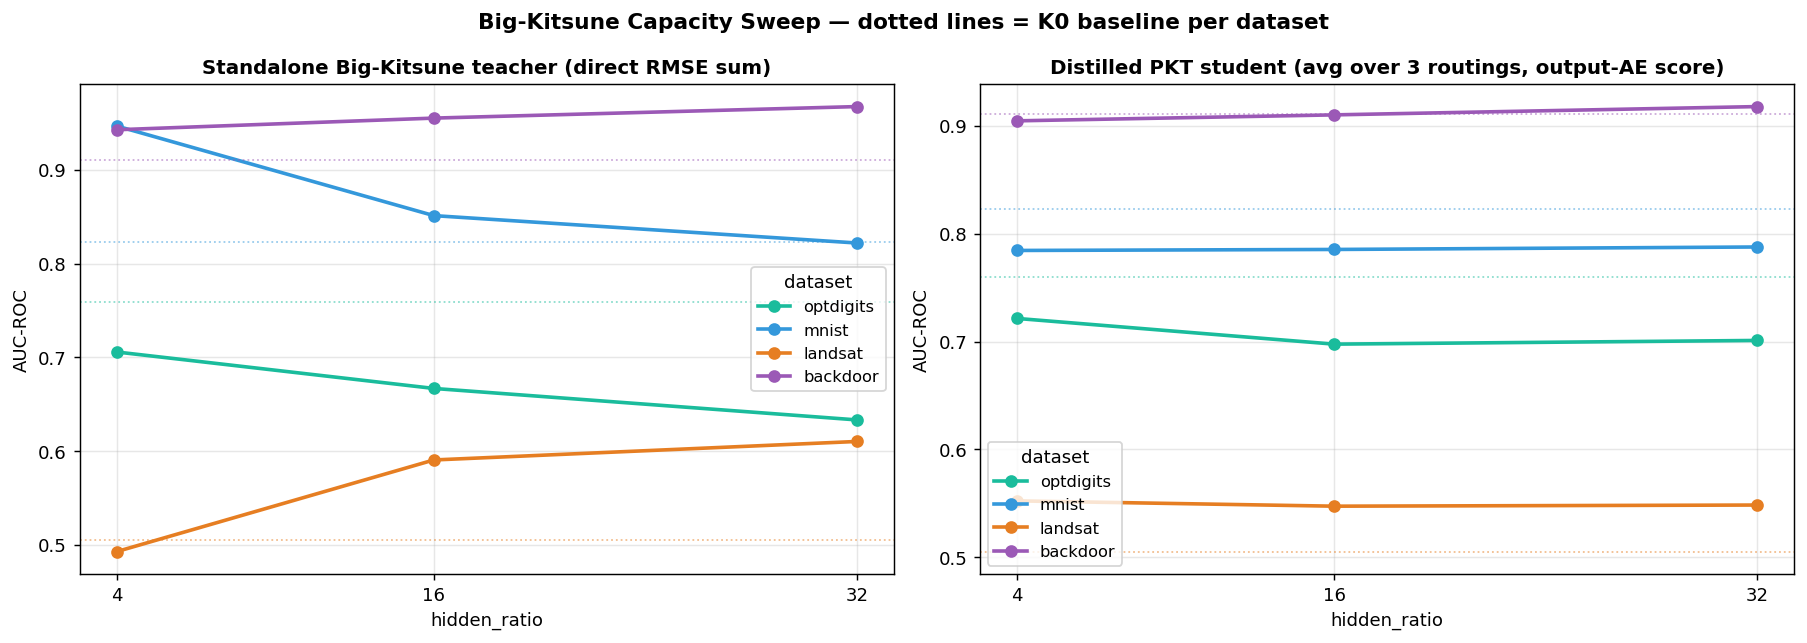

Teacher AUC (rows = hidden_ratio):
    optdigits  mnist  landsat  backdoor
4       0.706  0.947    0.493     0.943
16      0.667  0.851    0.590     0.955
32      0.633  0.822    0.610     0.968

Student AUC averaged over routings:
    optdigits  mnist  landsat  backdoor
4       0.721  0.785    0.552     0.905
16      0.698  0.785    0.547     0.910
32      0.701  0.788    0.548     0.918

K0 (kitsune_vanilla) baseline:
optdigits    0.760
mnist        0.823
landsat      0.505
backdoor     0.911


In [7]:
# Big-Kitsune capacity sweep — teacher AUC and (routing-averaged) student AUC vs hidden_ratio
mean_auc = df.groupby(['dataset', 'model'])['auc_roc'].mean()

teacher_curve = pd.DataFrame(
    {ds: [mean_auc.get((ds, f'bigkit_r{r}'), np.nan) for r in BIGKIT_RATIOS] for ds in DATASETS},
    index=BIGKIT_RATIOS,
)

# Average across the 3 routings (concat, per_subae, subae_paired) per (dataset, ratio)
def student_avg(ds, r):
    names = [
        f'kitsune_pkt_bigkit_r{r}',
        f'kitsune_pkt_bigkit_r{r}_per_subae',
        f'kitsune_pkt_bigkit_r{r}_subae_paired',
    ]
    vals = [mean_auc.get((ds, n)) for n in names]
    vals = [v for v in vals if v is not None and not np.isnan(v)]
    return float(np.mean(vals)) if vals else np.nan

student_curve = pd.DataFrame(
    {ds: [student_avg(ds, r) for r in BIGKIT_RATIOS] for ds in DATASETS},
    index=BIGKIT_RATIOS,
)

# K0 baseline horizontal reference per dataset
k0 = {ds: mean_auc.get((ds, BASELINE), np.nan) for ds in DATASETS}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
dataset_colors = dict(zip(DATASETS, ['#1abc9c', '#3498db', '#e67e22', '#9b59b6']))

for ax, (curve, title) in zip(axes, [
    (teacher_curve, 'Standalone Big-Kitsune teacher (direct RMSE sum)'),
    (student_curve, 'Distilled PKT student (avg over 3 routings, output-AE score)'),
]):
    for ds in DATASETS:
        ax.plot(BIGKIT_RATIOS, curve[ds], marker='o', linewidth=2, color=dataset_colors[ds], label=ds)
        ax.axhline(k0[ds], color=dataset_colors[ds], linestyle=':', linewidth=1, alpha=0.5)
    ax.set_xlabel('hidden_ratio')
    ax.set_ylabel('AUC-ROC')
    ax.set_xticks(BIGKIT_RATIOS)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(title='dataset', fontsize=9, loc='best')

plt.suptitle('Big-Kitsune Capacity Sweep — dotted lines = K0 baseline per dataset',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bigkit_capacity_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print('Teacher AUC (rows = hidden_ratio):')
print(teacher_curve.round(3).to_string())
print('\nStudent AUC averaged over routings:')
print(student_curve.round(3).to_string())
print('\nK0 (kitsune_vanilla) baseline:')
print(pd.Series(k0).round(3).to_string())